In [1]:
!pip install numpy pandas scikit-learn nltk

In [2]:
import numpy as np
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Acer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
import os
print(os.getcwd())

C:\Users\Acer\Fake_News_Detection\Notebook


In [26]:
fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

In [21]:
print(os.listdir())

['.ipynb_checkpoints', 'Fake_News_Detection.ipynb']


In [25]:
print(os.listdir('../data'))

['Fake.csv', 'True.csv']


In [27]:
fake_df['label'] = 0   
true_df['label'] = 1   

In [28]:
df = pd.concat([fake_df, true_df], axis=0)

# Shuffle data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [29]:
df['content'] = df['text']

In [53]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub('[^a-zA-Z]', ' ', str(text))
    text = text.lower().split()
    
    text = [lemmatizer.lemmatize(word, pos='v') for word in text if word not in stop_words]
    
    return ' '.join(text)

In [54]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=5,
    max_df=0.8)

X = tfidf.fit_transform(corpus)
y = df['label']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [57]:
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(loss='hinge')

In [58]:
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(loss='hinge')
model.fit(X_train, y_train)

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "SGDClassifier": model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Accuracy:", accuracy_score(y_test, y_pred))


Logistic Regression Accuracy: 0.9880846325167038

Naive Bayes Accuracy: 0.9512249443207127

SGDClassifier Accuracy: 0.9909799554565701


In [60]:
best_model = model

In [59]:
def predict_news(text):
    text = preprocess(text)
    vector = tfidf.transform([text])
    
    prediction = best_model.predict(vector)
    
    return "REAL NEWS 🟢" if prediction[0] == 1 else "FAKE NEWS 🔴"

In [61]:
print(predict_news("Government passes new healthcare bill"))
print(predict_news("Aliens secretly controlling world leaders"))

FAKE NEWS 🔴
FAKE NEWS 🔴


In [70]:
sample = df.sample(10)

for text, label in zip(sample['content'], sample['label']):
    print("News:", text[:100])  # first 100 chars
    print("Predicted:", predict_news(text), "| Actual:", "REAL" if label==1 else "FAKE")
    print("-"*80)


News: On Thursday, U.S. District Judge Daniel Jordan ruled Mississippi s discriminatory ban on allowing sa
Predicted: FAKE NEWS 🔴 | Actual: FAKE
--------------------------------------------------------------------------------
News:  InverseWikileaks released tonight a new cache of documents, showing that the United States  Nationa
Predicted: FAKE NEWS 🔴 | Actual: FAKE
--------------------------------------------------------------------------------
News: MOSCOW (Reuters) - President Vladimir Putin signed a decree on Thursday which said Russia s armed fo
Predicted: REAL NEWS 🟢 | Actual: REAL
--------------------------------------------------------------------------------
News: A woman who was born in Nazi Germany says that what reminds her of Hitler more than anything else is
Predicted: FAKE NEWS 🔴 | Actual: FAKE
--------------------------------------------------------------------------------
News: HANOI (Reuters) - Vietnam’s prime minister has urged a greater U.S. role in preventing mil

In [72]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for text, actual in test_samples:
    prediction = predict_news(text)
    predicted_label = 1 if "REAL" in prediction else 0
    
    y_true.append(actual)
    y_pred.append(predicted_label)

print(confusion_matrix(y_true, y_pred))

[[9 0]
 [9 0]]


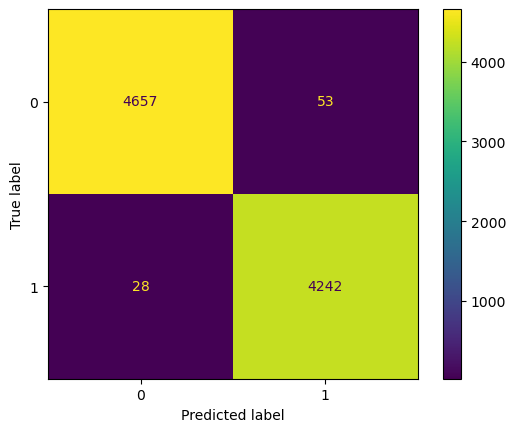

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [74]:
import pickle

pickle.dump(best_model, open('model.pkl', 'wb'))
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))